In [58]:
import utils
import numpy as np
import pandas as pd
import os
import importlib
import re
from matplotlib.pyplot import cm

importlib.reload(utils)

import matplotlib.pyplot as plt
import seaborn as sns # Loads in the theme

pd.set_option('future.no_silent_downcasting', True)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 1000)

In [59]:
# Make output folder
output_dir = os.path.join('..','..','plots','behavioural', 'win-stay-lose-shift')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [60]:
# Preparation
rerun_glob = True
if rerun_glob:
    pilot_analysis = False
    unique_subject_ids = [5, 10, 11, 14]#[802,803,804,805,806,807,808,809,810,811,813,814,815]
    unique_sessions = [2, 3, 4]
    plot_range = [0, 6]

    if pilot_analysis:
        raw_output_path = '/Volumes/project/3025011.02/pilot_data/phd_1_task/experiment_output/behavioural_files_pilot_2'
    else:
        raw_output_path = '/Volumes/project/3025011.02/raw/'
    recent_results = utils.analysis_functions.list_files_with_date_and_subject_id(raw_output_path, unique_subject_ids, unique_sessions)

In [61]:
if not recent_results:
    raise Exception('No files found')
print(recent_results)

['/Volumes/project/3025011.02/raw/sub-005/ses-mri02/beh/behavioural_output_sub-005_session-02_skyra_2025-03-14_11-00-23.csv', '/Volumes/project/3025011.02/raw/sub-005/ses-mri03/beh/behavioural_output_sub-005_session-03_skyra_2025-03-21_15-48-02.csv', '/Volumes/project/3025011.02/raw/sub-005/ses-mri04/beh/behavioural_output_sub-005_session-04_skyra_2025-03-28_15-50-17.csv', '/Volumes/project/3025011.02/raw/sub-010/ses-mri02/beh/behavioural_output_sub-010_session-02_skyra_2025-03-13_11-21-05.csv', '/Volumes/project/3025011.02/raw/sub-010/ses-mri03/beh/behavioural_output_sub-010_session-03_skyra_2025-03-19_11-41-24.csv', '/Volumes/project/3025011.02/raw/sub-010/ses-mri04/beh/behavioural_output_sub-010_session-04_skyra_2025-03-25_15-18-37.csv', '/Volumes/project/3025011.02/raw/sub-011/ses-mri02/beh/behavioural_output_sub-011_session-02_skyra_2025-04-04_16-07-03.csv', '/Volumes/project/3025011.02/raw/sub-011/ses-mri03/beh/behavioural_output_sub-011_session-03_skyra_2025-04-11_11-31-46.csv',

### Remove invalid files

In [62]:
# Remove files that contain invalid data
raw_output_path = '/Volumes/project/3025011.02/raw/'
invalid_data = pd.read_csv(f'{raw_output_path}../incomplete_data.csv', delimiter=';')
combinations = {
    f"sub-{row['subject-id']:03}_session-{row['session-number']:02}"
    for _, row in invalid_data[invalid_data['datatype'] == 'beh'].iterrows()
}
print(f'These participants will be excluded: {combinations}')

patterns = [re.compile(re.escape(combo)) for combo in combinations]
# Filter the list: remove any string that contains one of the combinations
recent_results = [
    item for item in recent_results
    if not any(pattern.search(item) for pattern in patterns)
]
print(recent_results)

These participants will be excluded: {'sub-003_session-03'}
['/Volumes/project/3025011.02/raw/sub-005/ses-mri02/beh/behavioural_output_sub-005_session-02_skyra_2025-03-14_11-00-23.csv', '/Volumes/project/3025011.02/raw/sub-005/ses-mri03/beh/behavioural_output_sub-005_session-03_skyra_2025-03-21_15-48-02.csv', '/Volumes/project/3025011.02/raw/sub-005/ses-mri04/beh/behavioural_output_sub-005_session-04_skyra_2025-03-28_15-50-17.csv', '/Volumes/project/3025011.02/raw/sub-010/ses-mri02/beh/behavioural_output_sub-010_session-02_skyra_2025-03-13_11-21-05.csv', '/Volumes/project/3025011.02/raw/sub-010/ses-mri03/beh/behavioural_output_sub-010_session-03_skyra_2025-03-19_11-41-24.csv', '/Volumes/project/3025011.02/raw/sub-010/ses-mri04/beh/behavioural_output_sub-010_session-04_skyra_2025-03-25_15-18-37.csv', '/Volumes/project/3025011.02/raw/sub-011/ses-mri02/beh/behavioural_output_sub-011_session-02_skyra_2025-04-04_16-07-03.csv', '/Volumes/project/3025011.02/raw/sub-011/ses-mri03/beh/behaviour

In [63]:
combined_results_dataframe = utils.analysis_functions.combine_result_files(recent_results)
if pilot_analysis:
    combined_results_dataframe.rename(columns={'iti': 'trial_duration'}, inplace=True)
    combined_results_dataframe['stimuli_type'] = combined_results_dataframe['stimuli_type'].replace(3, 2)
print(combined_results_dataframe)

      trial  emotional_cue_time response objectively_correct subjectively_correct  response_time   RT_s  feedback_time  stimuli_type  trial_duration  probability_condition  face_type stimuli_name  reward_amount subject_id     session
0         0        1.741947e+09     down                Even                False   1.741947e+09  0.692   1.741947e+09             1        3.704648                     50          3     Angry_b3           -0.1    sub-005  session-02
1         1        1.741947e+09       up                Even                 True   1.741947e+09  0.940   1.741947e+09             1        4.295352                     50          2     Angry_b2            0.0    sub-005  session-02
2         2        1.741947e+09       up                Even                 True   1.741947e+09  0.793   1.741947e+09             1        3.302849                     50          1     Angry_b1            0.1    sub-005  session-02
3         3        1.741947e+09     down                Even    

# Flip results if joystick orientation was incorrect
Specifically, switch the response and probability

In [64]:
# List of subject_session combinations to update
match_list = ['sub-004_session-04']

# Create a new column that combines subject_id and session in the same format as the list.
combined_results_dataframe['sub_session'] = combined_results_dataframe['subject_id'] + '_' + combined_results_dataframe['session']

# Create a mask for rows that match any of the combinations in match_list.
mask = combined_results_dataframe['sub_session'].isin(match_list)

# For 'probability_condition', swap 80 with 20 and vice versa.
combined_results_dataframe.loc[mask, 'probability_condition'] = (
    combined_results_dataframe.loc[mask, 'probability_condition']
    .replace({80: 20, 20: 80})
)

# For 'response', swap 'up' with 'down' and vice versa.
combined_results_dataframe.loc[mask, 'response'] = (
    combined_results_dataframe.loc[mask, 'response']
    .replace({'up': 'down', 'down': 'up'})
)

# Optionally, drop the helper column
combined_results_dataframe.drop(columns='sub_session', inplace=True)

print(combined_results_dataframe)

      trial  emotional_cue_time response objectively_correct subjectively_correct  response_time   RT_s  feedback_time  stimuli_type  trial_duration  probability_condition  face_type stimuli_name  reward_amount subject_id     session
0         0        1.741947e+09     down                Even                False   1.741947e+09  0.692   1.741947e+09             1        3.704648                     50          3     Angry_b3           -0.1    sub-005  session-02
1         1        1.741947e+09       up                Even                 True   1.741947e+09  0.940   1.741947e+09             1        4.295352                     50          2     Angry_b2            0.0    sub-005  session-02
2         2        1.741947e+09       up                Even                 True   1.741947e+09  0.793   1.741947e+09             1        3.302849                     50          1     Angry_b1            0.1    sub-005  session-02
3         3        1.741947e+09     down                Even    

# Analysis
First, we'll look at the reaction time. A plot with all the RT's and average will do.
Second we will look at the percentage of correct answers.
Lastly, we will be looking at a win-stay lose shift to see when behaviour stabilises after a shift in reward contingency.

In [65]:
# Count amount of subplots necessary based on subject_id's and sessions
## Finds unique values
unique_subject_ids = combined_results_dataframe['subject_id'].unique()
unique_sessions = combined_results_dataframe['session'].unique()

## Calculates the number of subplots needed
n_rows = len(unique_subject_ids)
n_cols = len(unique_sessions)
n_subplots = len(unique_sessions) * len(unique_subject_ids)

### Make additional columns for congruency, valence, WSLS and volatility

In [66]:
combined_results_dataframe['congruency'] = combined_results_dataframe.apply(utils.analysis_functions.check_congruency, axis=1)
print(combined_results_dataframe[['stimuli_type','probability_condition','congruency']])

      stimuli_type  probability_condition   congruency
0                1                     50    undefined
1                1                     50    undefined
2                1                     50    undefined
3                2                     50    undefined
4                2                     50    undefined
5                2                     50    undefined
6                2                     50    undefined
7                1                     50    undefined
8                1                     20  incongruent
9                2                     80  incongruent
10               2                     80  incongruent
11               1                     20  incongruent
12               1                     20  incongruent
13               2                     80  incongruent
14               1                     20  incongruent
15               1                     20  incongruent
16               2                     80  incongruent
17        

In [67]:
combined_results_dataframe['valence'] = combined_results_dataframe.apply(utils.analysis_functions.check_valence, axis=1)
print(combined_results_dataframe[['stimuli_type','valence']])

      stimuli_type valence
0                1   angry
1                1   angry
2                1   angry
3                2   happy
4                2   happy
5                2   happy
6                2   happy
7                1   angry
8                1   angry
9                2   happy
10               2   happy
11               1   angry
12               1   angry
13               2   happy
14               1   angry
15               1   angry
16               2   happy
17               2   happy
18               1   angry
19               1   angry
20               2   happy
21               2   happy
22               2   happy
23               1   angry
24               1   angry
25               2   happy
26               1   angry
27               1   angry
28               2   happy
29               2   happy
30               2   happy
31               2   happy
32               1   angry
33               1   angry
34               2   happy
35               1   angry
3

In [68]:
# Turns the objective values into boolean ones
mapping = {'True': 100, 'False': 0, 'Even': 0, 'Late': 0}
#pd.options.display.max_rows = None

combined_results_dataframe['objectively_correct_boolean'] = combined_results_dataframe['objectively_correct'].replace(mapping)
combined_results_dataframe['objectively_correct_boolean'] = combined_results_dataframe['objectively_correct_boolean'].astype('int')

In [69]:
# Add WSLS columns
combined_results_dataframe = utils.learning_models.add_WSLS_column(combined_results_dataframe)

     subject_id     session subjectively_correct_one_back subjectively_correct  same_response_as_one_back  WS_subjective  LS_subjective
0       sub-005  session-02                           NaN                False                          0              0              0
1       sub-005  session-02                         False                 True                          0              0              1
2       sub-005  session-02                          True                 True                          1              1              0
3       sub-005  session-02                          True                False                          0             -1              0
4       sub-005  session-02                         False                False                          0              0              1
5       sub-005  session-02                         False                False                          1              0             -1
6       sub-005  session-02                     

In [70]:
# Add volatility column
combined_results_dataframe = combined_results_dataframe[combined_results_dataframe['probability_condition'] != 50]
combined_results_dataframe = combined_results_dataframe.groupby('stimuli_type', group_keys=False).apply(lambda x: utils.analysis_functions.check_volatility(x))
combined_results_dataframe = combined_results_dataframe.sort_values(by=['subject_id','session','stimuli_type','trial'], ascending=[True, True, True, True])
print(combined_results_dataframe)

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_4618/2827216585.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  combined_results_dataframe = combined_results_dataframe.groupby('stimuli_type', group_keys=False).apply(lambda x: utils.analysis_functions.check_volatility(x))


      trial  emotional_cue_time response objectively_correct subjectively_correct  response_time   RT_s  feedback_time  stimuli_type  trial_duration  ...  objectively_correct_one_back  response_one_back same_response_as_one_back  response_two_back choicestickiness WS_subjective LS_subjective WS_objective  LS_objective volatility
0         8        1.741947e+09       up               False                False   1.741947e+09  0.635   1.741947e+09             1        3.983508  ...                          Even               down                         0                 up                0             0             1            0             0   volatile
1        11        1.741947e+09       up               False                False   1.741947e+09  0.931   1.741947e+09             1        4.544228  ...                         False                 up                         1               down                0             0            -1            0            -1   volatile
2      

# Win-stay plots
# Subjective win-stay behaviour

In [71]:
# Filter out the trials where there was no win-stay or win-shift
combos = combined_results_dataframe[['subject_id','session']].drop_duplicates().sort_values(['subject_id','session'])
print(combos)
combined_results_dataframe_WS = combined_results_dataframe[combined_results_dataframe['WS_subjective'] != 0]
combos = combined_results_dataframe_WS[['subject_id','session']].drop_duplicates().sort_values(['subject_id','session'])
print(combos)
# Replace -1 by 0's
combined_results_dataframe_WS['WS_subjective'] = combined_results_dataframe_WS['WS_subjective'].replace(-1, 0)
combined_results_dataframe_WS['WS_subjective'] = combined_results_dataframe_WS['WS_subjective'].replace(1, 100)

     subject_id     session
0       sub-005  session-02
330     sub-005  session-03
660     sub-005  session-04
990     sub-010  session-02
1320    sub-010  session-03
1650    sub-010  session-04
1980    sub-011  session-02
2310    sub-011  session-03
2640    sub-011  session-04
2970    sub-014  session-02
3300    sub-014  session-03
3630    sub-014  session-04
     subject_id     session
4       sub-005  session-02
331     sub-005  session-03
660     sub-005  session-04
990     sub-010  session-02
1324    sub-010  session-03
1652    sub-010  session-04
1980    sub-011  session-02
2310    sub-011  session-03
2640    sub-011  session-04
2970    sub-014  session-02
3300    sub-014  session-03
3631    sub-014  session-04


/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_4618/3466888734.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_dataframe_WS['WS_subjective'] = combined_results_dataframe_WS['WS_subjective'].replace(-1, 0)
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_4618/3466888734.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_dataframe_WS['WS_subjective'] = combined_results_dataframe_WS['WS_subjective'].replace(1, 100)


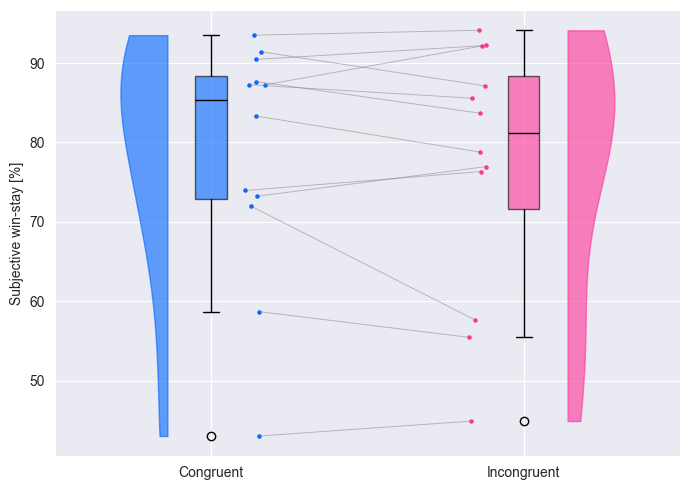

In [72]:
# Single-pass aggregation & reshape
combined_results_pivoted = (
    combined_results_dataframe_WS
    .pivot_table(
        index=['subject_id', 'session'],
        columns='congruency',
        values='WS_subjective',
        aggfunc='mean'
    )
    .reset_index()
)
combined_results_pivoted = combined_results_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud_2_groups(
    combined_results_pivoted,
    column_1='congruent',
    column_2='incongruent',
    labels=['Congruent', 'Incongruent'],
    output_dir=output_dir,
    ylabel_name='Subjective win-stay [%]',
    plot_name='all_trials_subjective_win-stay_congruency'
)

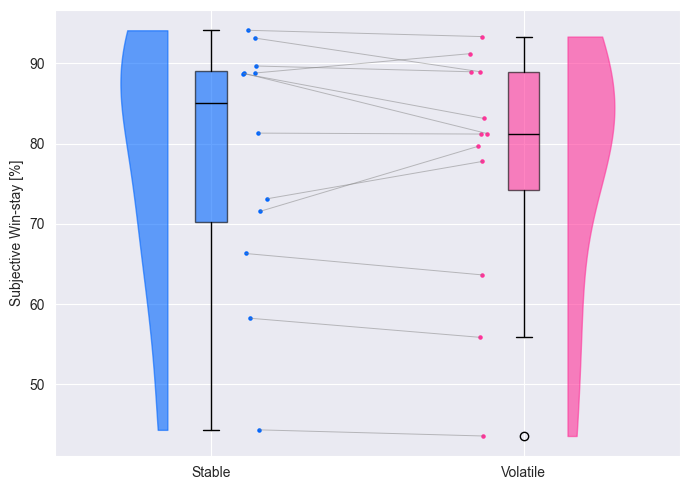

In [73]:
# Single-pass aggregation & reshape
combined_results_pivoted = (
    combined_results_dataframe_WS
    .pivot_table(
        index=['subject_id', 'session'],
        columns='volatility',
        values='WS_subjective',
        aggfunc='mean'
    )
    .reset_index()
)
combined_results_pivoted = combined_results_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud_2_groups(
    combined_results_pivoted,
    column_1='stable',
    column_2='volatile',
    labels=['Stable', 'Volatile'],
    output_dir=output_dir,
    ylabel_name='Subjective Win-stay [%]',
    plot_name='all_trials_subjective_win-stay_volatility'
)

## Objective win-stay behaviour

In [74]:
# Filter out the trials where there was no win-stay or win-shift
combos = combined_results_dataframe[['subject_id','session']].drop_duplicates().sort_values(['subject_id','session'])
print(combos)
combined_results_dataframe_WS = combined_results_dataframe[combined_results_dataframe['WS_objective'] != 0]
combos = combined_results_dataframe_WS[['subject_id','session']].drop_duplicates().sort_values(['subject_id','session'])
print(combos)
# Replace -1 by 0's
combined_results_dataframe_WS['WS_objective'] = combined_results_dataframe_WS['WS_objective'].replace(-1, 0)
combined_results_dataframe_WS['WS_objective'] = combined_results_dataframe_WS['WS_objective'].replace(1, 100)

     subject_id     session
0       sub-005  session-02
330     sub-005  session-03
660     sub-005  session-04
990     sub-010  session-02
1320    sub-010  session-03
1650    sub-010  session-04
1980    sub-011  session-02
2310    sub-011  session-03
2640    sub-011  session-04
2970    sub-014  session-02
3300    sub-014  session-03
3630    sub-014  session-04
     subject_id     session
4       sub-005  session-02
331     sub-005  session-03
661     sub-005  session-04
991     sub-010  session-02
1322    sub-010  session-03
1652    sub-010  session-04
1983    sub-011  session-02
2311    sub-011  session-03
2644    sub-011  session-04
2972    sub-014  session-02
3301    sub-014  session-03
3631    sub-014  session-04


/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_4618/1698204416.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_dataframe_WS['WS_objective'] = combined_results_dataframe_WS['WS_objective'].replace(-1, 0)
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_4618/1698204416.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_dataframe_WS['WS_objective'] = combined_results_dataframe_WS['WS_objective'].replace(1, 100)


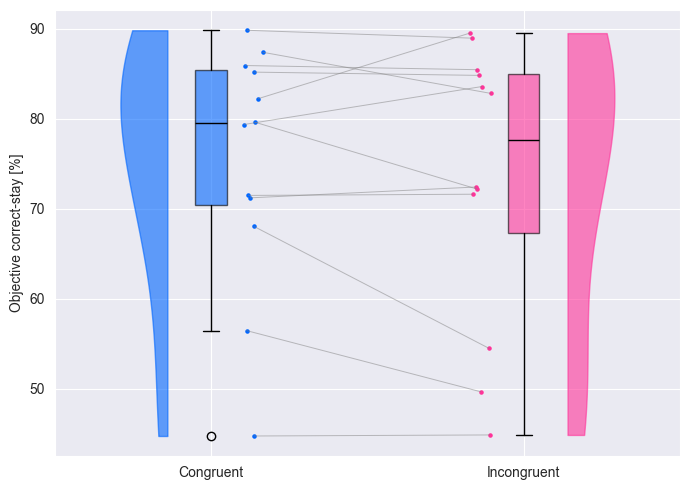

In [75]:
# Single-pass aggregation & reshape
combined_results_pivoted = (
    combined_results_dataframe_WS
    .pivot_table(
        index=['subject_id', 'session'],
        columns='congruency',
        values='WS_objective',
        aggfunc='mean'
    )
    .reset_index()
)
combined_results_pivoted = combined_results_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud_2_groups(
    combined_results_pivoted,
    column_1='congruent',
    column_2='incongruent',
    labels=['Congruent', 'Incongruent'],
    output_dir=output_dir,
    ylabel_name='Objective correct-stay [%]',
    plot_name='all_trials_objective_correct-stay_congruency'
)

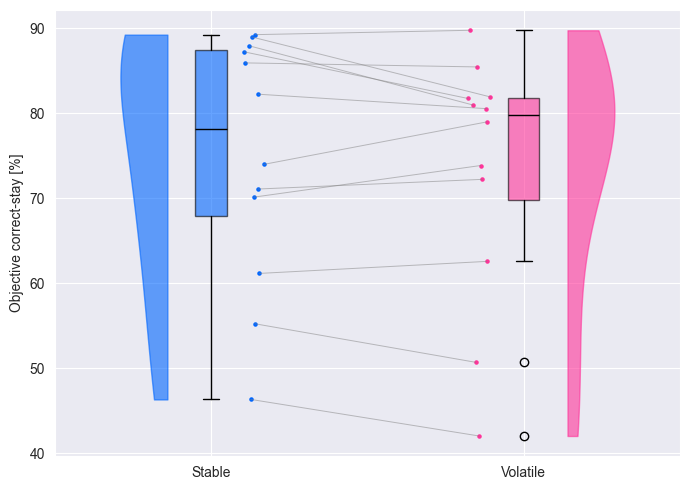

In [76]:
# Single-pass aggregation & reshape
combined_results_pivoted = (
    combined_results_dataframe_WS
    .pivot_table(
        index=['subject_id', 'session'],
        columns='volatility',
        values='WS_objective',
        aggfunc='mean'
    )
    .reset_index()
)
combined_results_pivoted = combined_results_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud_2_groups(
    combined_results_pivoted,
    column_1='stable',
    column_2='volatile',
    labels=['Stable', 'Volatile'],
    output_dir=output_dir,
    ylabel_name='Objective correct-stay [%]',
    plot_name='all_trials_objective_correct-stay_volatility'
)

# Lose-shift plots
## Subjective lose-stay behaviour

In [77]:
# Filter out the trials where there was no win-stay or win-shift
combined_results_dataframe_LS = combined_results_dataframe[combined_results_dataframe['LS_subjective'] != 0]
# Replace -1 by 0's
combined_results_dataframe_LS['LS_subjective'] = combined_results_dataframe_LS['LS_subjective'].replace(-1, 0)
combined_results_dataframe_LS['LS_subjective'] = combined_results_dataframe_LS['LS_subjective'].replace(1, 100)

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_4618/987488559.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_dataframe_LS['LS_subjective'] = combined_results_dataframe_LS['LS_subjective'].replace(-1, 0)
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_4618/987488559.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_dataframe_LS['LS_subjective'] = combined_results_dataframe_LS['LS_subjective'].replace(1, 100)


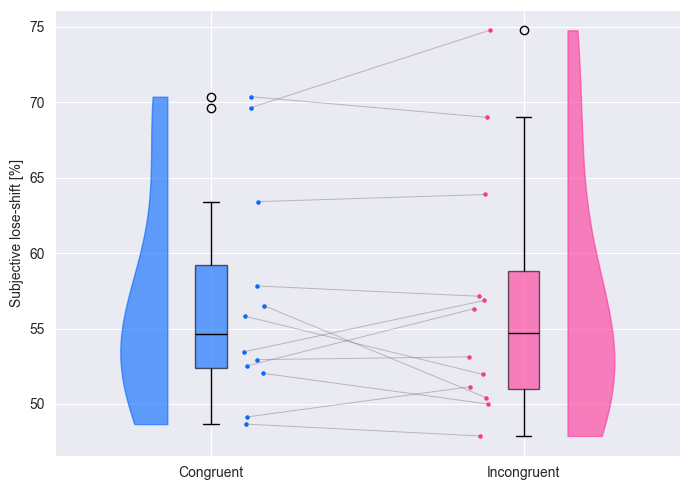

In [78]:
# Single-pass aggregation & reshape
combined_results_pivoted = (
    combined_results_dataframe_LS
    .pivot_table(
        index=['subject_id', 'session'],
        columns='congruency',
        values='LS_subjective',
        aggfunc='mean'
    )
    .reset_index()
)
combined_results_pivoted = combined_results_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud_2_groups(
    combined_results_pivoted,
    column_1='congruent',
    column_2='incongruent',
    labels=['Congruent', 'Incongruent'],
    output_dir=output_dir,
    ylabel_name='Subjective lose-shift [%]',
    plot_name='all_trials_subjective_lose-shift_congruency'
)

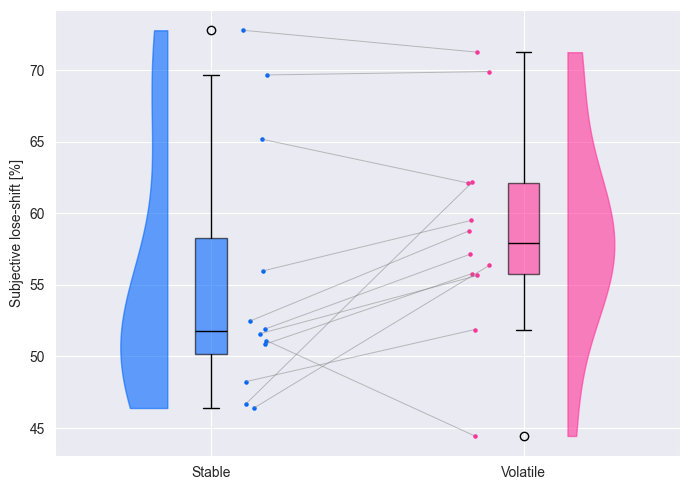

In [79]:
# Single-pass aggregation & reshape
combined_results_pivoted = (
    combined_results_dataframe_LS
    .pivot_table(
        index=['subject_id', 'session'],
        columns='volatility',
        values='LS_subjective',
        aggfunc='mean'
    )
    .reset_index()
)
combined_results_pivoted = combined_results_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud_2_groups(
    combined_results_pivoted,
    column_1='stable',
    column_2='volatile',
    labels=['Stable', 'Volatile'],
    output_dir=output_dir,
    ylabel_name='Subjective lose-shift [%]',
    plot_name='all_trials_subjective_lose-shift_volatility'
)

## Objective lose-stay behaviour

In [80]:
# Filter out the trials where there was no win-stay or win-shift
combined_results_dataframe_LS = combined_results_dataframe[combined_results_dataframe['LS_objective'] != 0]
# Replace -1 by 0's
combined_results_dataframe_LS['LS_objective'] = combined_results_dataframe_LS['LS_objective'].replace(-1, 0)
combined_results_dataframe_LS['LS_objective'] = combined_results_dataframe_LS['LS_objective'].replace(1, 100)

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_4618/2447323335.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_dataframe_LS['LS_objective'] = combined_results_dataframe_LS['LS_objective'].replace(-1, 0)
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_4618/2447323335.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_dataframe_LS['LS_objective'] = combined_results_dataframe_LS['LS_objective'].replace(1, 100)


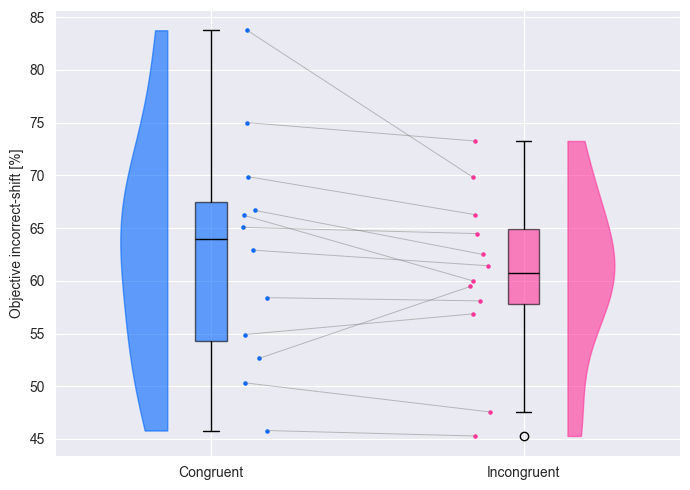

In [81]:
# Single-pass aggregation & reshape
combined_results_pivoted = (
    combined_results_dataframe_LS
    .pivot_table(
        index=['subject_id', 'session'],
        columns='congruency',
        values='LS_objective',
        aggfunc='mean'
    )
    .reset_index()
)
combined_results_pivoted = combined_results_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud_2_groups(
    combined_results_pivoted,
    column_1='congruent',
    column_2='incongruent',
    labels=['Congruent', 'Incongruent'],
    output_dir=output_dir,
    ylabel_name='Objective incorrect-shift [%]',
    plot_name='all_trials_objective_incorrect-shift_congruency'
)

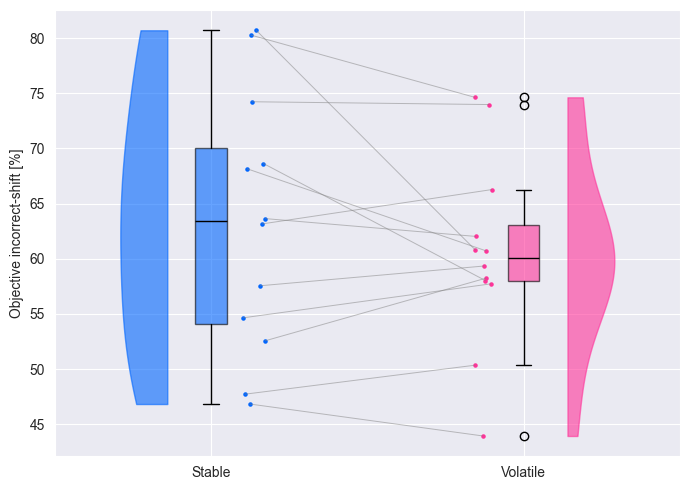

In [82]:
# Single-pass aggregation & reshape
combined_results_pivoted = (
    combined_results_dataframe_LS
    .pivot_table(
        index=['subject_id', 'session'],
        columns='volatility',
        values='LS_objective',
        aggfunc='mean'
    )
    .reset_index()
)
combined_results_pivoted = combined_results_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud_2_groups(
    combined_results_pivoted,
    column_1='stable',
    column_2='volatile',
    labels=['Stable', 'Volatile'],
    output_dir=output_dir,
    ylabel_name='Objective incorrect-shift [%]',
    plot_name='all_trials_objective_incorrect-shift_volatility'
)